In [9]:
# Install (kalau perlu)
!pip install scikit-learn matplotlib seaborn

# Import library
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer

Saving hellow word asssembly.png to hellow word asssembly (1).png


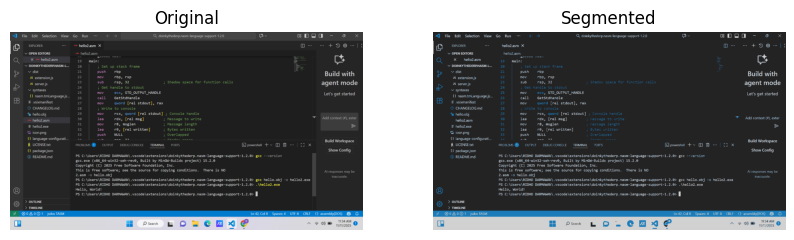

In [10]:
import cv2
from google.colab import files

uploaded = files.upload()

# Ambil nama file
file_name = list(uploaded.keys())[0]

# Baca image
img = cv2.imread(file_name)

# ERROR FIX: cek kalau gagal load
if img is None:
    raise ValueError("Image gagal dibaca, pastikan format jpg/png")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Reshape
pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(pixel_values)

centers = np.uint8(kmeans.cluster_centers_)
labels = kmeans.labels_

segmented = centers[labels]
segmented = segmented.reshape(img.shape)

# Plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Segmented")
plt.imshow(segmented)
plt.axis("off")

plt.show()